In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from fairlearn.metrics import MetricFrame
!pip install shap
import shap


In [2]:
train = pd.read_csv("/Users/sinclairmadden/Desktop/Responsible Data Science/Responsible Data Science Final Project/train.csv").drop(columns="id")
test = pd.read_csv("/Users/sinclairmadden/Desktop/Responsible Data Science/Responsible Data Science Final Project/test.csv").drop(columns="id")
sub = pd.read_csv("/Users/sinclairmadden/Desktop/Responsible Data Science/Responsible Data Science Final Project/sample_submission.csv")

In [3]:
le = LabelEncoder()

cat_cols = [
    'gender', 'course', 'internet_access', 'sleep_quality',
    'study_method', 'facility_rating', 'exam_difficulty'
]

for col in cat_cols:
    train[col] = le.fit_transform(train[col])

In [4]:
X = train.drop(columns=['exam_score'])
y = train['exam_score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = HistGradientBoostingRegressor(
    max_iter=1000,        
    learning_rate=0.05,   
    max_depth=10,         
    random_state=42
)

# Model Train
print("Model Training Start...")
model.fit(X_train, y_train)

# Prediction 
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n--- Result ---")
print(f"R2 Score (Accurry): {r2:.4f}")
print(f"MAE (Mean Absoult Error): {mae:.4f} ")

def predict_new_student(new_data_row):
    prediction = model.predict(new_data_row)
    return prediction

print("Done")

Model Training Start...

--- Result ---
R2 Score (Accurry): 0.7836
MAE (Mean Absoult Error): 6.9982 
Done


EDA on internet_access and facility_rating

In [7]:
# Check basic info
train[['internet_access', 'facility_rating']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   internet_access  630000 non-null  int64
 1   facility_rating  630000 non-null  int64
dtypes: int64(2)
memory usage: 9.6 MB


In [8]:
# Value counts
print(train['internet_access'].value_counts())
print(train['facility_rating'].value_counts())

internet_access
1    579423
0     50577
Name: count, dtype: int64
facility_rating
2    214082
1    212378
0    203540
Name: count, dtype: int64


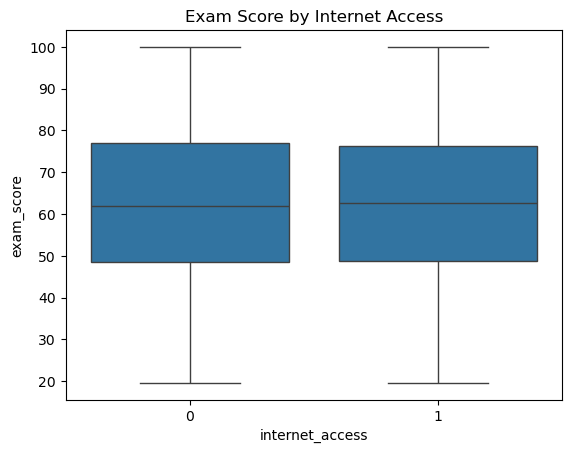

In [9]:
sns.boxplot(x='internet_access', y='exam_score', data=train)
plt.title('Exam Score by Internet Access')
plt.show()

In [10]:
train.groupby('internet_access')['exam_score'].mean()

internet_access
0    62.478038
1    62.509172
Name: exam_score, dtype: float64

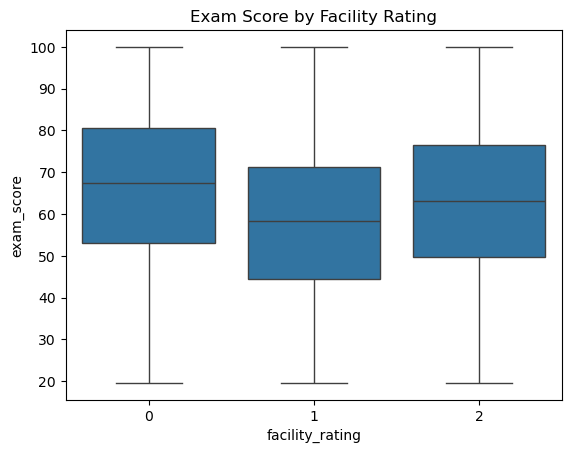

In [11]:
sns.boxplot(x='facility_rating', y='exam_score', data=train)
plt.title('Exam Score by Facility Rating')
plt.show()

In [12]:
train.groupby('facility_rating')['exam_score'].mean()

facility_rating
0    66.707126
1    57.954546
2    63.028954
Name: exam_score, dtype: float64

In [13]:
pivot = train.pivot_table(
    values='exam_score',
    index='facility_rating',
    columns='internet_access',
    aggfunc='mean'
)

print(pivot)

internet_access          0          1
facility_rating                      
0                66.946677  66.685883
1                57.505571  57.993724
2                63.107432  63.022205


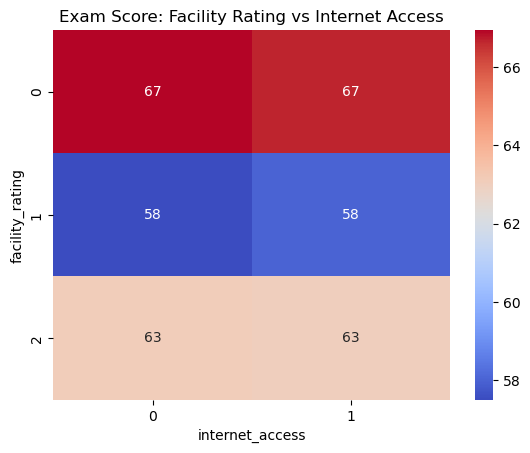

In [14]:
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Exam Score: Facility Rating vs Internet Access')
plt.show()

In [15]:
train['internet_access'].value_counts()

internet_access
1    579423
0     50577
Name: count, dtype: int64

In [16]:
train['facility_rating'].value_counts(dropna=False)

facility_rating
2    214082
1    212378
0    203540
Name: count, dtype: int64

In [17]:
train[['internet_access', 'facility_rating']].corr()

,internet_access,facility_rating
internet_access,1.000000,0.003389
facility_rating,0.003389,1.000000


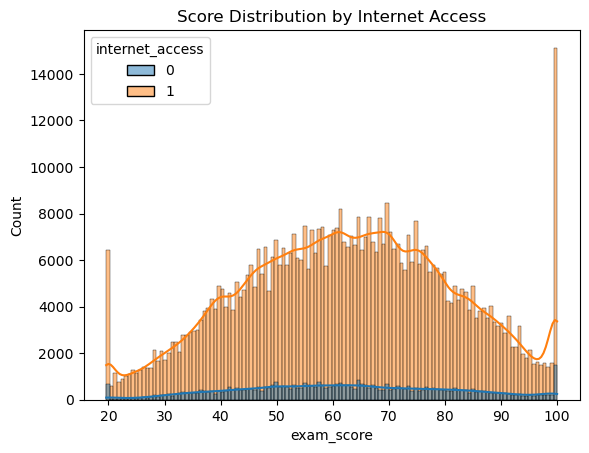

In [18]:
sns.histplot(data=train, x='exam_score', hue='internet_access', kde=True)
plt.title('Score Distribution by Internet Access')
plt.show()

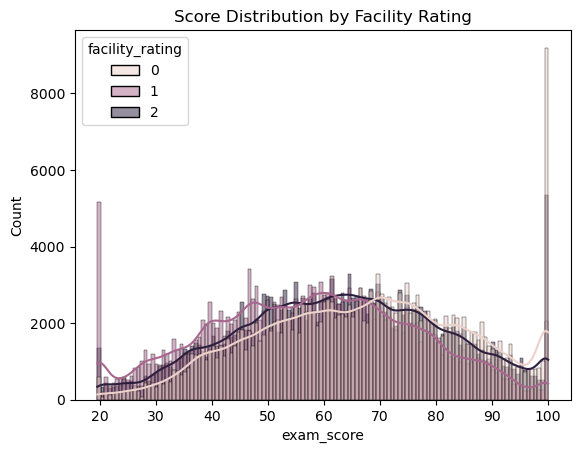

In [19]:
sns.histplot(data=train, x='exam_score', hue='facility_rating', kde=True)
plt.title('Score Distribution by Facility Rating')
plt.show()

## ADS

### MAE

In [6]:
results = X_test.copy()
results['actual_score'] = y_test
results['predicted_score'] = y_pred
results['residual'] = results['actual_score'] - results['predicted_score']
results['abs_residual'] = results['residual'].abs()

In [21]:
results.groupby('gender')['abs_residual'].mean()

gender
0    6.998882
1    6.986146
2    7.009385
Name: abs_residual, dtype: float64

In [22]:
results.groupby('facility_rating')['abs_residual'].mean()

facility_rating
0    7.037448
1    6.917663
2    7.040547
Name: abs_residual, dtype: float64

## Error

In [23]:
results.groupby('gender')['residual'].mean()

gender
0    0.038647
1    0.052839
2   -0.009471
Name: residual, dtype: float64

In [24]:
results.groupby('facility_rating')['residual'].mean()

facility_rating
0    0.099579
1    0.022397
2   -0.036216
Name: residual, dtype: float64

In [25]:
results.sort_values('abs_residual', ascending=False).head(10)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,actual_score,predicted_score,residual,abs_residual
553891,21,2,6,1.73,73.6,0,7.5,1,2,1,0,100.000,53.187221,46.812779,46.812779
87444,18,2,2,2.85,70.9,1,8.8,1,4,2,2,100.000,58.151628,41.848372,41.848372
199720,24,2,6,3.82,66.5,1,6.7,2,0,2,2,19.599,61.003980,-41.404980,41.404980
450474,18,1,3,6.03,91.9,1,9.1,0,0,1,1,48.500,87.040740,-38.540740,38.540740
629254,17,2,2,6.10,54.5,1,6.3,2,4,0,1,26.800,65.075283,-38.275283,38.275283
354978,24,2,2,7.32,53.5,1,7.3,1,4,0,2,45.800,83.456435,-37.656435,37.656435
308258,22,0,5,0.59,94.9,1,9.2,0,2,0,0,93.300,56.236439,37.063561,37.063561
435636,22,2,2,1.47,83.6,1,9.2,0,0,0,0,97.700,61.808390,35.891610,35.891610
298935,20,1,5,1.91,50.3,1,9.7,0,0,0,1,91.200,55.382348,35.817652,35.817652
479255,24,0,4,0.08,43.6,1,6.2,1,2,0,0,74.300,39.109753,35.190247,35.190247


## SHAP

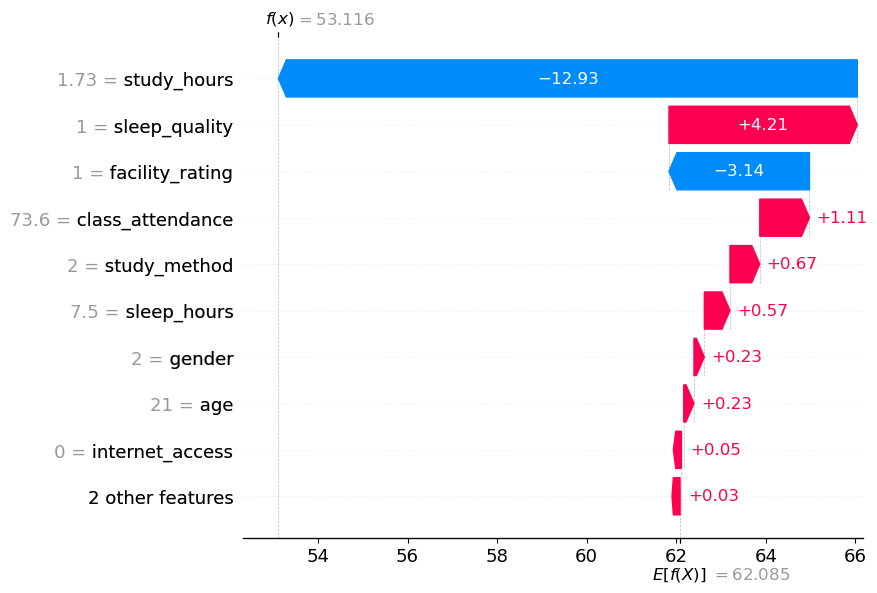

In [7]:
bg = X_train.sample(200, random_state=16)
explainer = shap.Explainer(model, bg)

worst_pos = results['abs_residual'].values.argmax()
X_explain = X_test.iloc[[worst_pos]]

shap_values = explainer(X_explain)
shap.plots.waterfall(shap_values[0])